## **A) LangGraph**

LangChain is the name of the company that provides different services under the following names :
- **LangChain** : For the GenAI applications. It is kind of a wrapper for LLM integration, embedding, Vector Database, etc. It also provides classes for Agentic AI implementation but you will not have low-level control over that. 
- **LangGraph** : Specifically made to make agentic AI implementations. Make agents from scratch
- **Langsmith/Langfuse** : Observability and logging purposes
- **Langflow** : Visualise flow, majorly a visualisation platform. 

### **1) Introduction of LangGraph**

LangGraph is an orchestrator framework which means we can connect multiple components to it and run them according to the flow. Inside the orchestrator we define a pipeline and inside the pipeline we add the components and arrangement inside the pipeline the flow is stablished and components are executed. 

Here every code is written in the form of nodes and edges. Nodes can be visualised as functions and functions can be connected to different edges. 

Information flows between nodes as states and edges are something that connects one node to another. 

1) Node : Function
2) Edge : Connection between the nodes
3) State : State is working data flowing between the nodes. State is passing the information from one node to another node while maintaining the state.

Edges can be of 2 types :
- Sequential edges
- Conditional edges 

In [16]:
def hello_node(input:str): # Here you already define dthe class of input by str
    return {"message": f"Hello,{input}"}

In [17]:
hello_node("Hemant")

{'message': 'Hello,Hemant'}

In [18]:
from typing_extensions import TypedDict

In [19]:
class State(TypedDict): # TypedDict can store the information in dictionary format
    message: str

In [20]:
state : State = {"message" : "Hello Python!"}

In [21]:
State

__main__.State

In [22]:
def hello_node(state:State): #Here you already defined the class of input by State which is nothing but a custom class defined above
    return {"message": f"Hello {state['message']}"}

In [23]:
from langgraph.graph import StateGraph, START, END

In [29]:
builder = StateGraph(State)
builder.add_node("First_hello_node", hello_node) # defined as name and then the function
builder.add_edge(START, "First_hello_node")
builder.add_edge("First_hello_node", END)

In [30]:
graph = builder.compile()

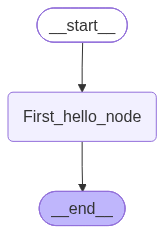

In [31]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
graph.invoke({"message": "Hemant"})

{'message': 'Hello Hemant'}

In [33]:
result = graph.invoke({"message": "Hemant"})
result["message"]

'Hello Hemant'

##### **Implementation 2**

In [ ]:
class Sunny(TypedDict):
    text: str

In [49]:
def function1(state:Sunny):
    print(f"State from first function : {state}")
    return {
        "text": state["text"] + " from first function"
        }

In [50]:
def function2(state:Sunny):
    print(f"State from second function : {state}")
    return {
        "text": state["text"] + " Dhingra from second function"
        }

In [51]:
workflow = StateGraph(Sunny)
workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)

In [52]:
workflow.add_edge(START, "fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", END)

In [53]:
app = workflow.compile()

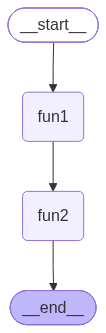

In [54]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [55]:
result = app.invoke({"text": "Hi this is Hemant"})

State from first function : {'text': 'Hi this is Hemant'}
State from second function : {'text': 'Hi this is Hemant from first function'}


In [56]:
result

{'text': 'Hi this is Hemant from first function Dhingra from second function'}

- State from first function before return (**this is input to the first function**) : {'text': 'Hi this is Hemant'}
- State from second function before return statement(**this is output from the first function and hence input to seconf function**): {'text': 'Hi this is Hemant from first function'}
- **final state after second function output** {'text': 'Hi this is Hemant from first function Dhingra from second function'}

##### **Implementation 3**

### **2) LangGraph Architecture**

### **3) State management in LangGraph**

### **4) StaleGraph vs Graph API vs Functional API**

### **5) Send API**

### **6) Command API**

### **7) Persistence/Checkpoint**

### **8) Memory**

### **9) Human IN Loop**

### **10) Streaming**

### **11) Multi-Agents**

### **12) Caching**

### **13) Fault Tolerance**

### **14) Async LangGraph**